# IV.2.2 — Spatial Characteristic Analysis of BISINDO Skeleton Data

This notebook generates visualizations to document **spatial issues/characteristics** found in the BISINDO skeleton data before pre-processing.

Three analysis groups:
1. **IV.2.2.1 — Position and Scale Variations Across Signers** → Scatter overlay, keypoint distance boxplot, multi-signer skeleton overlay
2. **IV.2.2.2 — Inter-frame Coordinate Instability (Micro-shift)** → Coordinate fluctuation line chart, displacement histogram
3. **IV.2.2.3 — [0,0] Coordinate Noise** → Noise frequency heatmap per keypoint, noise bar chart per signer, frame visualization with noise

---

In [1]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
from collections import defaultdict
import os

# ── Paper-style global rcParams (consistent with reference notebooks) ─────────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.linewidth'     : 0.8,
    'axes.grid'          : False,
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'figure.titlesize'   : 11,
    'figure.titleweight' : 'bold',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
})

# ── Color palette ─────────────────────────────────────────────────────────────
C_LH     = '#2166AC'   # Left hand  – deep blue
C_RH     = '#D6604D'   # Right hand – muted red
C_EDGE   = '#555555'   # Skeleton edges
C_NOISE  = '#B2182B'   # Noise highlight – red
C_VALID  = '#4393C3'   # Valid keypoint
GRAYS    = ['#1a1a1a', '#555555', '#888888', '#bbbbbb']
BAR_EC   = 'black'
BAR_LW   = 0.6

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = '../data/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hand skeleton edges ───────────────────────────────────────────────────────
HAND_EDGES = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]
CONNECTIONS = [(u,v) for u,v in HAND_EDGES] + [(u+21,v+21) for u,v in HAND_EDGES]

IDX_LH   = np.arange(0, 21)    # Left hand
IDX_RH   = np.arange(21, 42)   # Right hand
IDX_HAND = np.arange(0, 42)    # Both hands

print('Configuration loaded.')

Configuration loaded.


## 0. Load Data

In [2]:
# ── CONFIGURATION — adjust path to your directory structure ─────────────
PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

video_ids = list(data.keys())
print(f'Total videos : {len(video_ids)}')
print(f'Sample IDs   : {video_ids[:1]}')

# Extract signer info from video ID (format: Pxx_Sxxx_Rxx)
speakers = sorted(set(v.split('_')[0] for v in video_ids))
print(f'Signers      : {speakers}')

# Keypoint layout (86 points):
# [0:21]  = Left Hand  (21 pts)
# [21:42] = Right Hand (21 pts)
# [42:61] = Mouth      (19 pts)
# [61:86] = Pose/Body  (25 pts)
K_TOTAL = 86

Total videos : 807
Sample IDs   : ['P1_S01_R1']
Signers      : ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']


---
## IV.3.1.3 — Keypoint Hilang dengan Koordinat [0,0]

Dua visualisasi:
- **Fig F** — Grouped bar: persentase frame dengan keypoint hilang per penutur (LH vs RH)
- **Fig G** — Skeleton frame visualization: contoh frame dengan missing keypoints


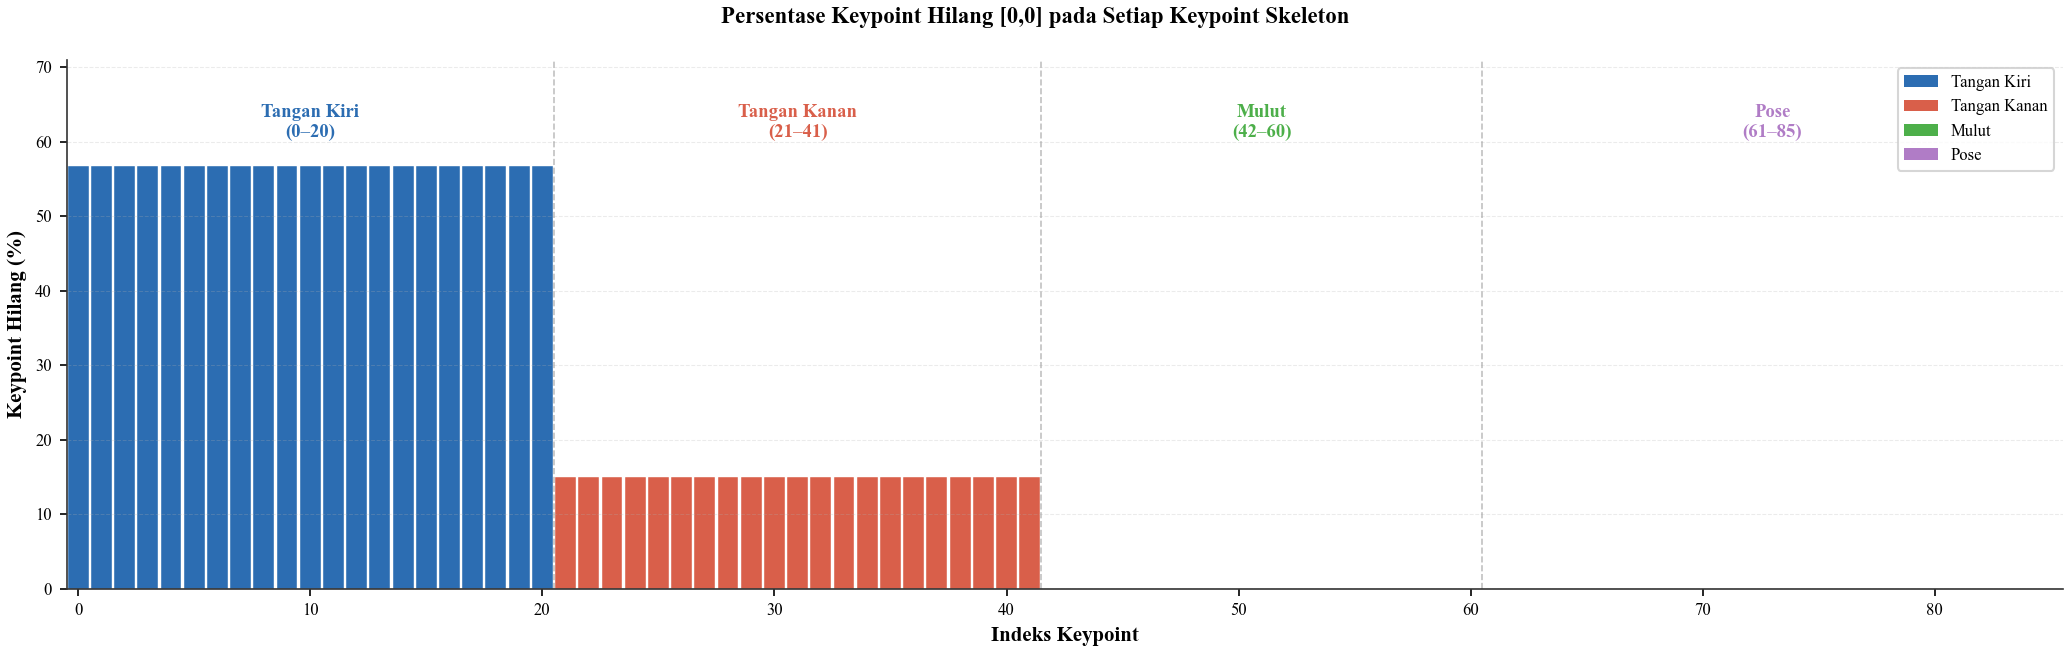

[SAVED] spatial_G_missing_per_keypoint.png


In [8]:
# ── Gambar IV.30: Persentase Keypoint Hilang [0,0] per Keypoint ──────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

N_KEYPOINTS = 86

# ── Hitung missing rate per keypoint ──────────────────────────────────────────
missing_count = np.zeros(N_KEYPOINTS)
total_count = 0

for vid in video_ids:

    kp = data[vid]['keypoints']      # (T, 86, 2)

    miss = (
        (kp[:, :, 0] == 0) &
        (kp[:, :, 1] == 0)
    )

    missing_count += miss.sum(axis=0)
    total_count += kp.shape[0]

missing_rate = (missing_count / total_count) * 100

# ── Warna per bagian tubuh ────────────────────────────────────────────────────
colors = []

for i in range(N_KEYPOINTS):

    if i <= 20:          # Left Hand
        colors.append('#2C6DB2')

    elif i <= 41:        # Right Hand
        colors.append('#D95F4A')

    elif i <= 60:        # Mouth
        colors.append('#4DAF4A')

    else:                # Pose
        colors.append('#B07CC6')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4.5), dpi=150)

bars = ax.bar(
    np.arange(N_KEYPOINTS),
    missing_rate,
    color=colors,
    width=0.9,
    edgecolor='white',
    linewidth=0.2
)

# ── Pemisah antar kelompok ────────────────────────────────────────────────────
for xline in [20.5, 41.5, 60.5]:
    ax.axvline(
        xline,
        color='#999999',
        linestyle='--',
        linewidth=0.8,
        alpha=0.6
    )

# ── Label kelompok ────────────────────────────────────────────────────────────
y_top = missing_rate.max() * 1.06

ax.text(
    10, y_top,
    'Tangan Kiri\n(0–20)',
    ha='center',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    color='#2C6DB2'
)

ax.text(
    31, y_top,
    'Tangan Kanan\n(21–41)',
    ha='center',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    color='#D95F4A'
)

ax.text(
    51, y_top,
    'Mulut\n(42–60)',
    ha='center',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    color='#4DAF4A'
)

ax.text(
    73, y_top,
    'Pose\n(61–85)',
    ha='center',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    color='#B07CC6'
)

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xlabel(
    'Indeks Keypoint',
    fontsize=10,
    fontweight='bold'
)

ax.set_ylabel(
    'Keypoint Hilang (%)',
    fontsize=10,
    fontweight='bold'
)

ax.set_xlim(-0.5, 85.5)
ax.set_ylim(0, missing_rate.max() * 1.25)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25,
    linewidth=0.5
)

ax.tick_params(
    axis='both',
    labelsize=8
)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend_elements = [
    Patch(facecolor='#2C6DB2', label='Tangan Kiri'),
    Patch(facecolor='#D95F4A', label='Tangan Kanan'),
    Patch(facecolor='#4DAF4A', label='Mulut'),
    Patch(facecolor='#B07CC6', label='Pose')
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=8,
    frameon=True
)

plt.suptitle(
    'Persentase Keypoint Hilang [0,0] pada Setiap Keypoint Skeleton',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'spatial_G_missing_per_keypoint.png'
    ),
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print('[SAVED] spatial_G_missing_per_keypoint.png')

── Missing Frame Rate per Signer ──
  Signer     LH (%)     RH (%)
      P1       61.3        8.9
      P2       21.2        3.2
      P3       64.2       19.7
      P4       72.5       24.0
      P5       64.1       18.3
      P6       64.9       16.8


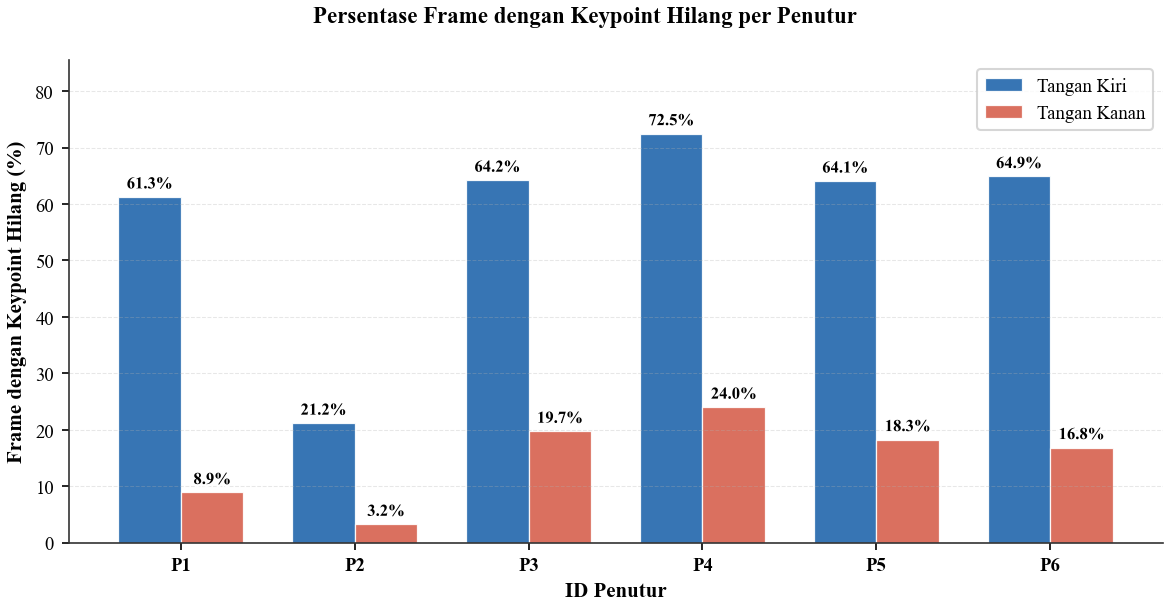

[SAVED] spatial_F_missing_per_signer.png


In [7]:
# ── Fig F: Missing Keypoint Rate per Signer (LH vs RH) ───────────────────────

import matplotlib.patheffects as pe

# ── Compute per-signer missing frame rate ────────────────────────────────────
sp_miss_lh = {}
sp_miss_rh = {}

for sp in speakers:
    sp_vids = [v for v in video_ids if v.startswith(sp)]

    total_f = 0
    n_lh = 0
    n_rh = 0

    for vid in sp_vids:
        kp = data[vid]['keypoints']  # (T, K, 2)
        T = kp.shape[0]

        miss_lh = (
            (kp[:, :21, 0] == 0) &
            (kp[:, :21, 1] == 0)
        ).any(axis=1)

        miss_rh = (
            (kp[:, 21:42, 0] == 0) &
            (kp[:, 21:42, 1] == 0)
        ).any(axis=1)

        total_f += T
        n_lh += miss_lh.sum()
        n_rh += miss_rh.sum()

    sp_miss_lh[sp] = n_lh / total_f * 100 if total_f > 0 else 0
    sp_miss_rh[sp] = n_rh / total_f * 100 if total_f > 0 else 0

# ── Summary table ────────────────────────────────────────────────────────────
print('── Missing Frame Rate per Signer ──')
print(f"{'Signer':>8} {'LH (%)':>10} {'RH (%)':>10}")

for sp in sorted(speakers):
    print(
        f"{sp:>8} "
        f"{sp_miss_lh[sp]:>10.1f} "
        f"{sp_miss_rh[sp]:>10.1f}"
    )

# ── Plot ─────────────────────────────────────────────────────────────────────
sp_sorted = sorted(speakers)

x = np.arange(len(sp_sorted))
w = 0.36

fig, ax = plt.subplots(figsize=(8.0, 4.2), dpi=150)

b_lh = ax.bar(
    x - w/2,
    [sp_miss_lh[s] for s in sp_sorted],
    width=w,
    color=C_LH,
    edgecolor='white',
    linewidth=0.6,
    alpha=0.90,
    label='Tangan Kiri'
)

b_rh = ax.bar(
    x + w/2,
    [sp_miss_rh[s] for s in sp_sorted],
    width=w,
    color=C_RH,
    edgecolor='white',
    linewidth=0.6,
    alpha=0.90,
    label='Tangan Kanan'
)

# ── Value labels with white outline ──────────────────────────────────────────
for bars in [b_lh, b_rh]:
    for bar in bars:

        h = bar.get_height()

        txt = ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.8,
            f'{h:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold',
            color='black'
        )

        txt.set_path_effects([
            pe.withStroke(
                linewidth=2.5,
                foreground='white'
            )
        ])

# ── Axes formatting ──────────────────────────────────────────────────────────
ymax = max(
    max(sp_miss_lh.values()),
    max(sp_miss_rh.values())
)

ax.set_ylim(0, ymax * 1.18)

ax.set_xticks(x)
ax.set_xticklabels(
    sp_sorted,
    fontsize=9,
    fontweight='bold'
)

ax.set_xlabel(
    'ID Penutur',
    fontsize=10,
    fontweight='bold'
)

ax.set_ylabel(
    'Frame dengan Keypoint Hilang (%)',
    fontsize=10,
    fontweight='bold'
)

ax.tick_params(
    axis='both',
    labelsize=9,
    colors='black'
)

ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(
    frameon=True,
    edgecolor='#cccccc',
    fontsize=9,
    loc='upper right'
)

plt.suptitle(
    'Persentase Frame dengan Keypoint Hilang per Penutur',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'spatial_F_missing_per_signer.png'
    ),
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print('[SAVED] spatial_F_missing_per_signer.png')

Selected frames (5 signers target):
  P1 | P1_S01_R1 | frame   0 | LH=21/21 RH=0/21 Total=21/42 | LH-dominant
  P2 | P2_S01_R1 | frame 145 | LH=0/21 RH=21/21 Total=21/42 | RH-dominant
  P4 | P4_S01_R1 | frame   0 | LH=21/21 RH=21/21 Total=42/42 | balanced
  P5 | P5_S01_R1 | frame   0 | LH=21/21 RH=21/21 Total=42/42 | balanced
  P3 | P3_S01_R1 | frame   0 | LH=21/21 RH=21/21 Total=42/42 | balanced


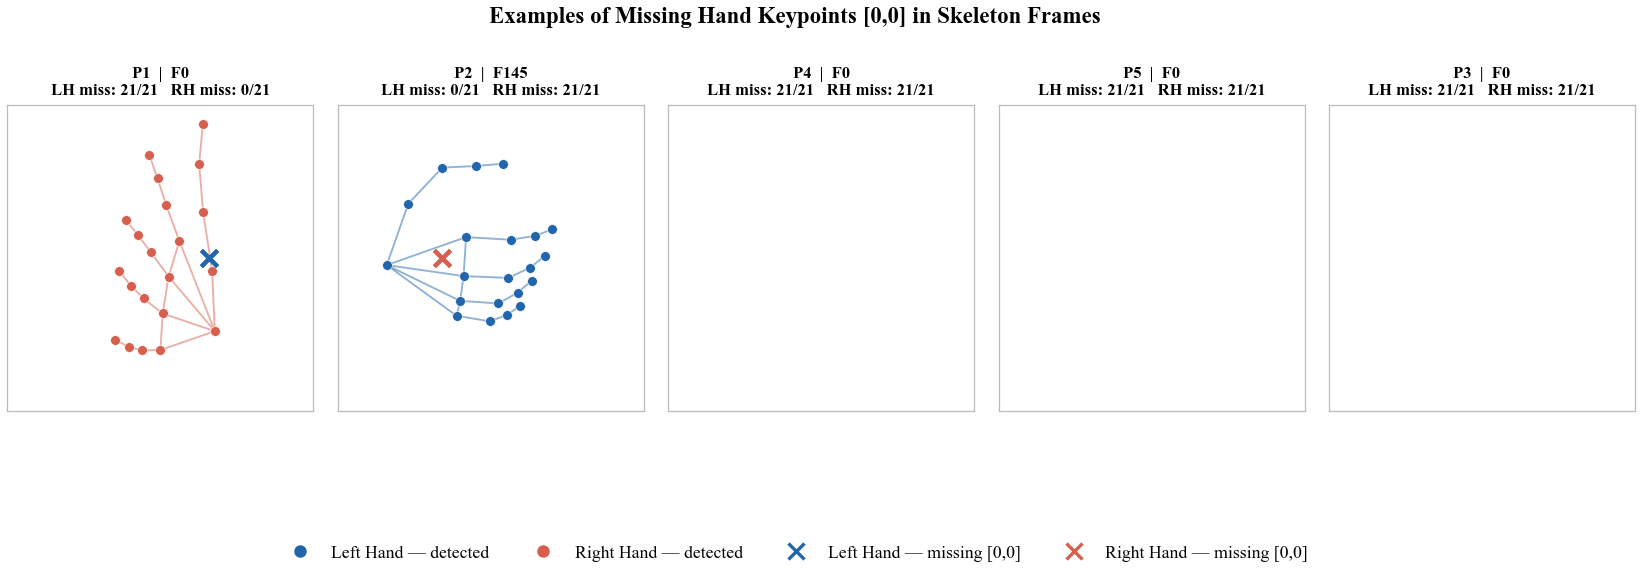

[SAVED] spatial_G_missing_frames.png


In [4]:
# ── Fig G: Examples of Missing Hand Keypoints [0,0] in Skeleton Frames ────────
# Exactly 5 unique signers, with LH-dominant and RH-dominant missing examples.

from matplotlib.lines import Line2D

HAND_EDGES_LOCAL = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]
CONN_HAND = [(u,v) for u,v in HAND_EDGES_LOCAL] + [(u+21,v+21) for u,v in HAND_EDGES_LOCAL]

IDX_LH_V = np.arange(0, 21)
IDX_RH_V = np.arange(21, 42)

ADJ = {i: [] for i in range(21)}
for u, v in HAND_EDGES_LOCAL:
    ADJ[u].append(v)
    ADJ[v].append(u)

def estimate_missing_pos(fp, is_miss, offset):
    positions = []
    for local_idx in range(21):
        g = local_idx + offset
        if not is_miss[g]:
            continue
        valid_nb = [n for n in ADJ[local_idx] if not is_miss[n + offset]]
        if len(valid_nb) >= 2:
            pts = np.array([fp[n + offset] for n in valid_nb[:2]])
            ex, ey = pts.mean(axis=0)
        elif len(valid_nb) == 1:
            ex, ey = fp[valid_nb[0] + offset]
        else:
            valid_grp = [i for i in range(21) if not is_miss[i + offset]]
            if valid_grp:
                pts = np.array([fp[i + offset] for i in valid_grp])
                ex, ey = pts.mean(axis=0)
            else:
                ex = 0.04 if offset == 0 else -0.04
                ey = 0.0
        positions.append((ex, ey))
    return positions

# Build candidate pool: (sp, vid, fi, lh, rh, total, gap)
records = []
for vid in video_ids:
    kp = data[vid]['keypoints'][:, :42, :]
    miss_lh = ((kp[:, :21, 0] == 0) & (kp[:, :21, 1] == 0)).sum(axis=1)
    miss_rh = ((kp[:, 21:, 0] == 0) & (kp[:, 21:, 1] == 0)).sum(axis=1)
    sp = vid.split('_')[0]
    for fi in range(kp.shape[0]):
        lh = int(miss_lh[fi]); rh = int(miss_rh[fi])
        tot = lh + rh
        if tot == 0:
            continue
        records.append((sp, vid, fi, lh, rh, tot, abs(lh - rh)))

if len(records) == 0:
    raise ValueError('No frames with missing keypoints were found.')

pool_lh_dom = [r for r in records if r[3] > r[4]]
pool_rh_dom = [r for r in records if r[4] > r[3]]
pool_all = sorted(records, key=lambda r: (r[5], r[6]), reverse=True)

selected = []
used_signers = set()
used_pairs = set()

def add_first_valid(pool):
    for rec in pool:
        sp, vid, fi, lh, rh, tot, gap = rec
        if sp in used_signers:
            continue
        if (vid, fi) in used_pairs:
            continue
        selected.append(rec)
        used_signers.add(sp)
        used_pairs.add((vid, fi))
        return True
    return False

# Mandatory coverage
pool_lh_dom = sorted(pool_lh_dom, key=lambda r: (r[3] - r[4], r[5]), reverse=True)
pool_rh_dom = sorted(pool_rh_dom, key=lambda r: (r[4] - r[3], r[5]), reverse=True)
has_lh = add_first_valid(pool_lh_dom)
has_rh = add_first_valid(pool_rh_dom)

# Fill remaining slots with most informative frames from new signers
for rec in pool_all:
    if len(selected) >= 5:
        break
    sp, vid, fi, lh, rh, tot, gap = rec
    if sp in used_signers or (vid, fi) in used_pairs:
        continue
    selected.append(rec)
    used_signers.add(sp)
    used_pairs.add((vid, fi))

# If still less than 5, allow repeated signers but unique frames
if len(selected) < 5:
    for rec in pool_all:
        if len(selected) >= 5:
            break
        sp, vid, fi, lh, rh, tot, gap = rec
        if (vid, fi) in used_pairs:
            continue
        selected.append(rec)
        used_pairs.add((vid, fi))

selected = selected[:5]

print('Selected frames (5 signers target):')
for sp, vid, fi, lh_n, rh_n, tot_n, _ in selected:
    tag = 'LH-dominant' if lh_n > rh_n else ('RH-dominant' if rh_n > lh_n else 'balanced')
    print(f'  {sp} | {vid} | frame {fi:3d} | LH={lh_n}/21 RH={rh_n}/21 Total={tot_n}/42 | {tag}')
if not has_lh:
    print('[WARN] LH-dominant sample not found.')
if not has_rh:
    print('[WARN] RH-dominant sample not found.')

# Global axis scale
panel_sides = []
for sp, vid, fi, lh_n, rh_n, tot_n, _ in selected:
    frame = data[vid]['keypoints'][fi, :42, :].copy().astype(float)
    is_miss = (frame[:, 0] == 0) & (frame[:, 1] == 0)
    vidx = np.where(~is_miss)[0]
    if len(vidx) == 0:
        continue
    cx = frame[vidx, 0].mean(); cy = frame[vidx, 1].mean()
    fp = frame.copy()
    fp[:, 0] = -(fp[:, 0] - cx)
    fp[:, 1] = -(fp[:, 1] - cy)
    vpts = fp[vidx]
    panel_sides.append(max(vpts[:, 0].ptp(), vpts[:, 1].ptp()))

global_side = max(panel_sides) * 1.35 if panel_sides else 0.22
global_side = max(global_side, 0.22)

# Plot
n_cols = len(selected)
fig, axes = plt.subplots(1, n_cols, figsize=(2.8 * n_cols, 3.8), dpi=150)
if n_cols == 1:
    axes = [axes]

for ax, (sp, vid, fi, lh_n, rh_n, tot_n, _) in zip(axes, selected):
    frame = data[vid]['keypoints'][fi, :42, :].copy().astype(float)
    is_miss = (frame[:, 0] == 0) & (frame[:, 1] == 0)
    is_valid = ~is_miss

    vidx = np.where(is_valid)[0]
    if len(vidx) > 0:
        cx = frame[vidx, 0].mean(); cy = frame[vidx, 1].mean()
        fp = frame.copy()
        fp[:, 0] = -(fp[:, 0] - cx)
        fp[:, 1] = -(fp[:, 1] - cy)

        for u, v in CONN_HAND:
            if is_valid[u] and is_valid[v]:
                col = C_LH if u < 21 else C_RH
                ax.plot([fp[u, 0], fp[v, 0]], [fp[u, 1], fp[v, 1]],
                        color=col, linewidth=0.9, alpha=0.50, zorder=2)

        for idx_grp, col in [(IDX_LH_V, C_LH), (IDX_RH_V, C_RH)]:
            v_idx = idx_grp[is_valid[idx_grp]]
            if len(v_idx):
                ax.scatter(fp[v_idx, 0], fp[v_idx, 1],
                           s=22, color=col, edgecolors='white', linewidths=0.3, zorder=3)

        for idx_grp, col, offset in [(IDX_LH_V, C_LH, 0), (IDX_RH_V, C_RH, 21)]:
            miss_local = [i for i in range(21) if is_miss[i + offset]]
            if not miss_local:
                continue
            positions = estimate_missing_pos(fp, is_miss, offset)
            for ex, ey in positions:
                ax.scatter(ex, ey, marker='x', s=55, color=col,
                           linewidths=1.6, zorder=5, alpha=0.9)

    ax.set_xlim(-global_side / 2, global_side / 2)
    ax.set_ylim(-global_side / 2, global_side / 2)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color('#BBBBBB')

    ax.set_title(
        f'{sp}  |  F{fi}\n'
        f'LH miss: {lh_n}/21   RH miss: {rh_n}/21',
        fontsize=8, pad=5
    )

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_LH,
           markersize=7, label='Left Hand — detected'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_RH,
           markersize=7, label='Right Hand — detected'),
    Line2D([0], [0], marker='x', color=C_LH, markersize=8,
           markeredgewidth=1.6, linestyle='none', label='Left Hand — missing [0,0]'),
    Line2D([0], [0], marker='x', color=C_RH, markersize=8,
           markeredgewidth=1.6, linestyle='none', label='Right Hand — missing [0,0]'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=8.5)

plt.suptitle('Examples of Missing Hand Keypoints [0,0] in Skeleton Frames', fontsize=11, fontweight='bold')
plt.subplots_adjust(wspace=0.08, bottom=0.20)
plt.savefig(os.path.join(OUTPUT_DIR, 'spatial_G_missing_frames.png'), dpi=600)
plt.show()
print('[SAVED] spatial_G_missing_frames.png')

In [5]:
# Cell intentionally left empty — Fig H replaced by Fig G above.
print('Done.')


Done.
